In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
df = pd.read_csv('/content/drive/MyDrive/Courses/2023 Fall CMPE 257/Colab/Perceptron/synthetic_dataset.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x1      50 non-null     float64
 1   x2      50 non-null     float64
 2   y       50 non-null     int64  
dtypes: float64(2), int64(1)
memory usage: 1.3 KB


Prep the dataset with the x0 column

In [3]:
df['x0'] = 1
cols = ['x0', 'x1', 'x2', 'y']
df = df[cols]

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x0      50 non-null     int64  
 1   x1      50 non-null     float64
 2   x2      50 non-null     float64
 3   y       50 non-null     int64  
dtypes: float64(2), int64(2)
memory usage: 1.7 KB


<Axes: xlabel='x1', ylabel='x2'>

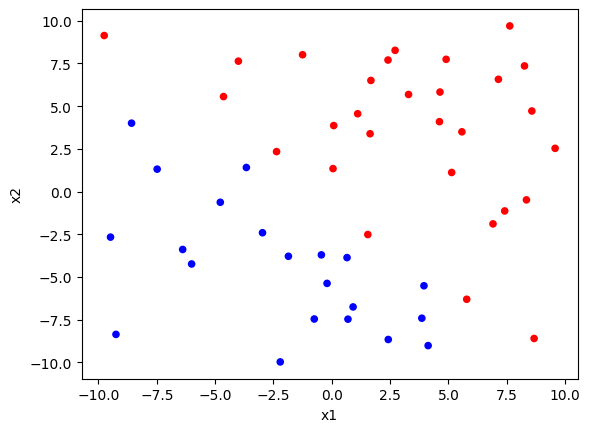

In [5]:
col = df['y'].map({-1:'b', 1:'r'})
df.plot.scatter(x='x1', y='x2', c=col)

In [6]:
df_sample = df.sample(n=40)
df_sample.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 40 entries, 13 to 18
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x0      40 non-null     int64  
 1   x1      40 non-null     float64
 2   x2      40 non-null     float64
 3   y       40 non-null     int64  
dtypes: float64(2), int64(2)
memory usage: 1.6 KB


<Axes: xlabel='x1', ylabel='x2'>

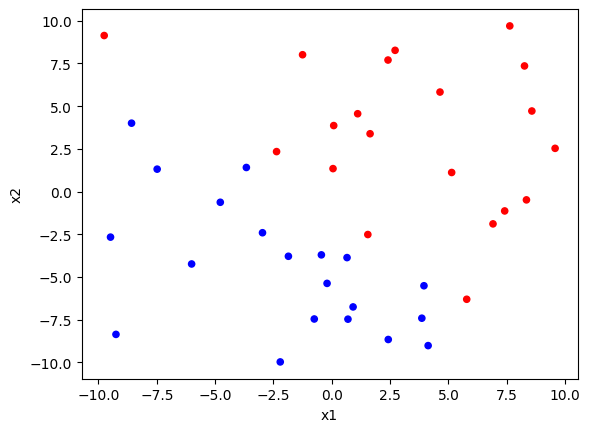

In [7]:
col = df_sample['y'].map({-1:'b', 1:'r'})
df_sample.plot.scatter(x='x1', y='x2', c=col)

PLA Code and Helpers

In [8]:
def sign(x):
    if x >= 0:
        return 1
    else:
        return -1

def get_sign(x, w):
  dot_product = x[0]*w[0] + x[1]*w[1] + x[2]*w[2]
  return sign(dot_product)

In [9]:
# x includes y as the last column
def findMisclassified(x, y, w):
    for (x_i, y_i) in zip(x, y):
      s = get_sign(x_i, w)
      if s*y_i < 0:
          return x_i, y_i
    return [], 0

In [10]:
def PLA(df):
  w = [0, 0, 0] #initialize w
  df_x = df.iloc[:, 0:3]
  df_y = df.iloc[:, 3]
  iters = 0
  while True:
    x_mis, y_mis = findMisclassified(df_x.values, df_y.values, w)
    if y_mis == 0:
      break
    iters = iters + 1
    print("x_mis: ", x_mis, "; y_mis: ", y_mis)
    w = w + x_mis * y_mis
    new_y = get_sign(x_mis, w)
    print("new_y: ", new_y)
  print(iters)
  return w

In [11]:
w = PLA(df)
print(w)

x_mis:  [ 1.          4.12796855 -9.02491201] ; y_mis:  -1
new_y:  -1
x_mis:  [1.         5.1364167  1.11332641] ; y_mis:  1
new_y:  1
x_mis:  [ 1.          1.54355617 -2.51962581] ; y_mis:  1
new_y:  -1
x_mis:  [ 1.          1.54355617 -2.51962581] ; y_mis:  1
new_y:  -1
x_mis:  [ 1.          1.54355617 -2.51962581] ; y_mis:  1
new_y:  1
x_mis:  [ 1.         -4.64177026  5.55855572] ; y_mis:  1
new_y:  1
x_mis:  [ 1.          1.54355617 -2.51962581] ; y_mis:  1
new_y:  -1
x_mis:  [ 1.          1.54355617 -2.51962581] ; y_mis:  1
new_y:  1
x_mis:  [ 1.         -9.75561638  9.13456539] ; y_mis:  1
new_y:  1
x_mis:  [1.         5.1364167  1.11332641] ; y_mis:  1
new_y:  1
x_mis:  [ 1.          1.54355617 -2.51962581] ; y_mis:  1
new_y:  -1
x_mis:  [ 1.          1.54355617 -2.51962581] ; y_mis:  1
new_y:  -1
x_mis:  [ 1.          1.54355617 -2.51962581] ; y_mis:  1
new_y:  1
x_mis:  [ 1.         -3.66249313  1.40660126] ; y_mis:  -1
new_y:  -1
x_mis:  [ 1.         -4.64177026  5.55855572]

Plot the DF and the line

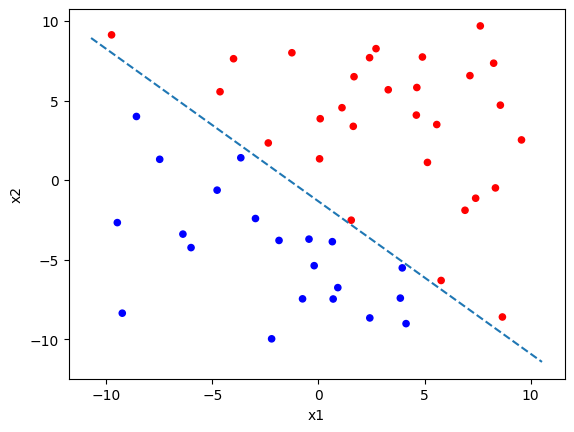

In [12]:
col = df['y'].map({-1:'b', 1:'r'})
df.plot.scatter(x='x1', y='x2', c=col)
axes = plt.gca()
x_vals = np.array(axes.get_xlim())
y_vals = -w[0]/w[2] - w[1]/w[2] * x_vals
plt.plot(x_vals, y_vals, '--')

Pocket Algorithm

In [ ]:
# x includes y as the last column
def findNumMisclassified(x, y, w):
  mis = 0
  for (x_i, y_i) in zip(x, y):
    s = get_sign(x_i, w)
    if s*y_i <= 0:
      mis = mis + 1
  return mis

In [ ]:
def Pocket(df):
  max_iters = 1000
  w_pocket = [0, 0, 0] #initialize w
  w = [0, 0, 0]
  df_x = df.iloc[:, 0:3]
  df_y = df.iloc[:, 3]
  iters = 0
  num_mis_pocket = findNumMisclassified(df_x.values, df_y.values, w_pocket)
  print(num_mis_pocket)
  while True:
    x_mis, y_mis = findMisclassified(df_x.values, df_y.values, w)
    if (y_mis == 0) or (iters > max_iters):
      break
    iters = iters + 1
    w = w_pocket + x_mis * y_mis
    num_mis = findNumMisclassified(df_x.values, df_y.values, w)
    if num_mis < num_mis_pocket:
      print("Changing pocket at iter ", iters)
      w_pocket = w
      num_mis_pocket = num_mis
  print(iters)
  return w_pocket

In [ ]:
w = Pocket(df)
print(w)

21
Changing pocket at iter  1
Changing pocket at iter  2
Changing pocket at iter  3
Changing pocket at iter  4
1001
[2.         4.09556048 5.0989868 ]


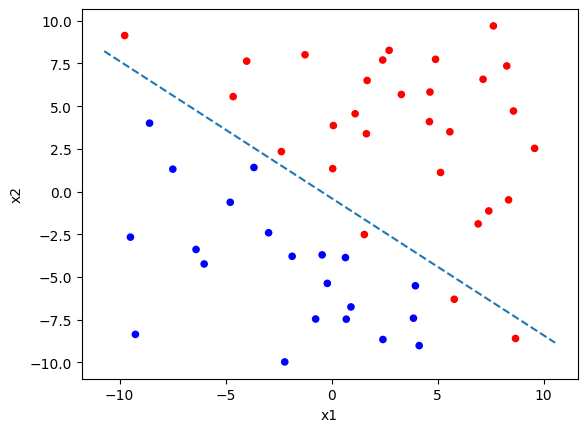

In [ ]:
col = df['y'].map({-1:'b', 1:'r'})
df.plot.scatter(x='x1', y='x2', c=col)
axes = plt.gca()
x_vals = np.array(axes.get_xlim())
y_vals = -w[0]/w[2] - w[1]/w[2] * x_vals
plt.plot(x_vals, y_vals, '--')